In [1]:
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

#Create training dataset from an indicated folder.
train_ds = image_dataset_from_directory(
    #Path folder
    r'E:\Coursera\CM3070 - Final Project\dataset\ORGANIZED_final\ROI\Train',
    #Labels are inferred from folders names.
    labels='inferred',
    #Binary classification (BENIGN or 0; MALIGNANT or 1).
    label_mode='binary',
    class_names=['BENIGN', 'MALIGNANT'],
    #Number of images processed in each batch.
    batch_size=32,
    #The dataset images are resized to 250x250.
    image_size=(250,250),
    #Crop and pad instructions to adapt images original size to the target size.
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False,
    #The images are in grayscale (1 channel).
    color_mode='grayscale',
    #In the training dataset, shuffle improves the training. 
    #It is not necessary shuffle in validation and test dataset. 
    shuffle=True
)

Found 2864 files belonging to 2 classes.


In [2]:
#Create validation dataset from an indicated folder.
#The code structure is the same of the train dataset (first dataset created) - only change the shuffle mode.
val_ds = image_dataset_from_directory(
    r'E:\Coursera\CM3070 - Final Project\dataset\ORGANIZED_final\ROI\Val',
    labels='inferred',
    label_mode='binary',
    class_names=['BENIGN', 'MALIGNANT'],
    batch_size=32,
    image_size=(250,250),
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False,
    color_mode='grayscale',
    shuffle=False
)

Found 348 files belonging to 2 classes.


In [3]:
#Create test dataset from an indicated folder.
#The code structure is the same of the train dataset (first dataset created) - only change the shuffle mode.
test_ds = image_dataset_from_directory(
    r'E:\Coursera\CM3070 - Final Project\dataset\ORGANIZED_final\ROI\Test',
    labels='inferred',
    label_mode='binary',
    class_names=['BENIGN', 'MALIGNANT'],
    batch_size=32,
    image_size=(250,250),
    crop_to_aspect_ratio=True,
    pad_to_aspect_ratio=False,
    color_mode='grayscale',
    shuffle=False
)

Found 356 files belonging to 2 classes.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

#Define a sequential CNN model.
model = models.Sequential([
    #Input: it is expects grayscale (1 channel) images of size 250x250. 
    layers.Input(shape=(250, 250, 1)),

    #Normalize pixel values from [0,255] to [0, 1].
    layers.Rescaling(1./255),

    #First Convolutional Sequence (32 filters).
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),

    #Second Convolutional Sequence (64 filters).
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),

    #Third Convolutional Sequence (128 filters).
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),

    #Conection between convolutional and dense layers (alternative to flatten layer).
    layers.GlobalAveragePooling2D(),

    #Dense layer (fully connected) (128 neurons).
    layers.Dense(128, activation='relu'),

    #Dropout layer - randomly disables a percentage of neurons.
    layers.Dropout(0.5),

    #Output layer for binary classification (1 neuron), with sigmoid activation function to calculate
    #a probability between 0 and 1 (probability of the input image is classified as class 1 - MALIGNANT).
    layers.Dense(1, activation='sigmoid')
])

#Compile model.
model.compile(
    #Optimizer Adam with learning rate of 0.0001.
    optimizer= tf.keras.optimizers.Adam(1e-4),
    #Loss Binary crossentropy because it is a binary classification.
    loss='binary_crossentropy',
    #Evaluation metrics (accuracy, precision and recall).
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()]
)

#Display the model architecture (layers, output shape and number of parameter of each layer, total number of parmeters).
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 250, 250, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 250, 250, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 250, 250, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 125, 125, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 62, 62, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
#Create a callback to save the model during the training.
checkpoint_save = tf.keras.callbacks.ModelCheckpoint(
    #Folder to save the model.
    filepath='checkpoints_final_ROI_4/model_epoch_{epoch:03d}.keras',
    #The entire model is saved at the end of each epoch (architecture + weights + optimizer state).
    save_weights_only=False,
    save_freq='epoch',
    #Messages of saving are off.
    verbose=0
)

In [6]:
#Train the model using the training dataset and validate it using the validation dataset.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    #Number of training iterations over the entire dataset.
    epochs=500,
    #Call callbacks to save the model.
    callbacks=[checkpoint_save]
)

Epoch 1/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 81s 883ms/step - accuracy: 0.5974 - loss: 0.6628 - precision: 0.5163 - recall: 0.3760 - val_accuracy: 0.6063 - val_loss: 0.6760 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 80s 893ms/step - accuracy: 0.6152 - loss: 0.6480 - precision: 0.5483 - recall: 0.3793 - val_accuracy: 0.6063 - val_loss: 0.6708 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 87s 963ms/step - accuracy: 0.6215 - loss: 0.6438 - precision: 0.5626 - recall: 0.3692 - val_accuracy: 0.6063 - val_loss: 0.7047 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 84s 932ms/step - accuracy: 0.6274 - loss: 0.6354 - precision: 0.5661 - recall: 0.4132 - val_accuracy: 0.6063 - val_loss: 0.7332 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/500
90/90 ━━━━━━━━━━━━━━━━━━━━ 82s 915ms/step - accuracy: 0.6271 - loss: 0.6353 - precision: 0.5667 - recall: 0.

In [7]:
#Create a variable to store model/network metrics history.
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])

In [8]:
import matplotlib.pyplot as plt

#Define function to plot training loss and validation loss. Code from the reference book.
def loss_history (history_dict):
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']

    epochs = range(1, len(loss) + 1)

    blue_dots = 'bo'
    solid_blue_line = 'b'

    plt.plot(epochs, loss, blue_dots, label = 'Training loss')
    plt.plot(epochs, val_loss, solid_blue_line, label = 'Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

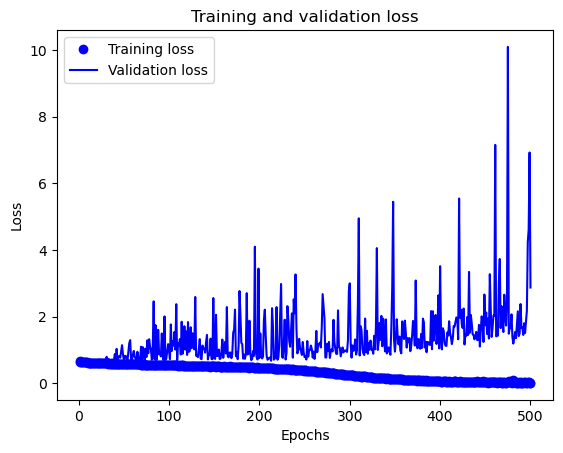

In [9]:
#Plot training loss and validation loss.
loss_history (history_dict)

In [10]:
val_loss= history.history['val_loss']

In [11]:
#Check min validation loss.
min_val_loss= min(val_loss)
min_val_loss

0.6664727926254272

In [12]:
#Search epoch related to the min validation loss.
import numpy as np
epoch_min_val_loss=np.argmin(val_loss)+1
epoch_min_val_loss

np.int64(29)

In [13]:
#Define function to plot training loss and validation accuracy. Code from the reference book.
def acc_history(history_dict):
    plt.clf()

    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']

    epochs = range(1, len(acc) + 1)

    blue_dots = 'bo'
    solid_blue_line = 'b'

    plt.plot(epochs, acc, blue_dots, label = 'Training acc')
    plt.plot(epochs, val_acc, solid_blue_line, label = 'Validation acc')
    plt.title('Training and validation acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

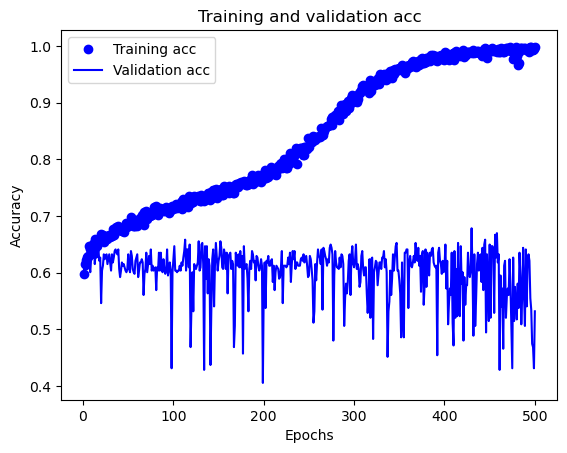

In [14]:
#Plot training accuracy and validation accuracy.
acc_history(history_dict)

In [15]:
val_accuracy= history.history['val_accuracy']

In [16]:
#Check max validation accuracy.
max_val_acc= max(val_accuracy)
max_val_acc

0.6781609058380127

In [17]:
#Search epoch related to the max validation accuracy.
epoch_max_val_acc=np.argmax(val_accuracy)+1
epoch_max_val_acc

np.int64(430)

In [18]:
#Check metrics for validation dataset on the final epoch.
model.evaluate(val_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5316 - loss: 2.8738 - precision: 0.4492 - recall: 0.8394        


[2.8737590312957764, 0.5316091775894165, 0.44921875, 0.8394160866737366]

In [19]:
#Check metrics for test dataset on the final epoch.
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.5056 - loss: 3.4550 - precision: 0.4297 - recall: 0.8129        


[3.4550254344940186,
 0.5056179761886597,
 0.42965778708457947,
 0.8129496574401855]

In [20]:
#Load saved model from disk, where was detect the max accuracy on validation dataset.
model = tf.keras.models.load_model(
    'checkpoints_final_ROI_4/model_epoch_430.keras'
)

In [21]:
#Check metrics for validation dataset on the loaded model (higher accuracy on validation dataset).
model.evaluate(val_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.6782 - loss: 1.9894 - precision: 0.6923 - recall: 0.3285        


[1.9894274473190308,
 0.6781609058380127,
 0.692307710647583,
 0.32846716046333313]

In [22]:
#Check metrics for test dataset on the loaded model (higher accuracy on validation dataset).
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.7051 - loss: 1.7436 - precision: 0.8148 - recall: 0.3165        


[1.7436496019363403, 0.7050561904907227, 0.8148148059844971, 0.316546767950058]

In [23]:
#Check metrics for (validation+test) dataset on the loaded model (higher accuracy on validation dataset).
combined_ds=val_ds.concatenate(test_ds)
model.evaluate(combined_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.6918 - loss: 1.8651 - precision: 0.7479 - recall: 0.3225        


[1.8651423454284668,
 0.6917613744735718,
 0.7478991746902466,
 0.3224637806415558]

C:\Users\rafaeldefendi\AppData\Local\Temp\ipykernel_16464\4267083830.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_name = class_names[int(label)]


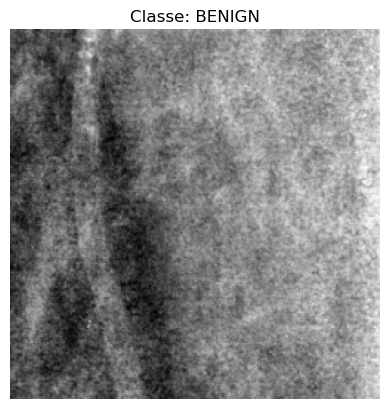

In [24]:
#Print image from dataset - example.
import matplotlib.pyplot as plt

#Batch
for images, labels in test_ds.take(2):
    img = images[15].numpy()
    label = labels[15].numpy()

#Grayscale
img = img.squeeze()

#Class
class_names = ['BENIGN', 'MALIGNANT']
label_name = class_names[int(label)]

#Image
plt.imshow(img, cmap='gray')
plt.title(f"Classe: {label_name}")
plt.axis("off")
plt.show()

In [38]:
#Example 1 of image label x prediction model. 
for images, labels in test_ds.take(1):
    img = images[0]
    label = labels[0]

pred = model.predict(tf.expand_dims(img, 0))

print("Label:", label.numpy())
print("Predction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Label: [0.]
Predction: [[0.00298299]]


In [39]:
#Example 2 of image label x prediction model. 
for images, labels in test_ds.take(9):
    img = images[1]
    label = labels[1]

pred = model.predict(tf.expand_dims(img, 0))

print("Label:", label.numpy())
print("Predction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Label: [1.]
Predction: [[0.9366319]]
